# Assignment 1 - 3 weeks.  
### Grading=> 4/10, 3/10, 3/10
### Exercise 1: create a seismic shot gather
Part 1;
Plot a seismic reflection with z0=200m,dt=0.004s, vel=1500m/s. \
Assume your wavelet is full-band (spike).\
Then plot its FK amplitude spectrum (average for all traces) and its FK spectrum.\
The fk_spectrum function is given, you can use a linear event to test that it works.\
Par 2: add 3 reflectors with depth=[200, 300, 470], (set different depth in a list, and loop through its elements.)


In [2]:
def fk_spectrum(d,dt,dx,freq_cut=0):
    # Author: Hongliang Zhang
    if (freq_cut==0):
        freq_cut=int(1/(2*dt)-1)
    
    nt,nx=d.shape
    nf=np.int(2 ** (np.ceil(np.log2(nt)) + 1))
    nkx=np.int(2 ** (np.ceil(np.log2(nx + 2)) + 1))
    
    d_fk=np.real(np.fft.fftshift(np.fft.fft2(d,(nf,nkx))))
    d_fk=d_fk / np.max(d_fk)
    
    nf2=nf / 2 + 2
    ifreq=np.arange(1,nf+1)
    ifreq2=ifreq - 1 - nf*np.floor(ifreq/nf2)
    freq=ifreq2 / nf / dt
    
    nkx2=nkx / 2 + 2
    ikx=np.arange(1,nkx+1)
    ikx2=ikx - 1 - nkx*np.floor(ikx / nkx2)
    kx2=ikx2 / nkx / dx
    kx=np.hstack((kx2[np.int(nkx/2+2):nkx],kx2[0:np.int(nkx/2+2)]))
    
    if (freq_cut > 0):
        dfreq=1 / nf / dt
        ifreq_cut=np.int(round(freq_cut / dfreq) + 1)
        freq=freq[range(ifreq_cut)]
        d_fk=d_fk[np.arange(np.int(nf/2),np.int(nf/2+ifreq_cut)),:]
        
    return d_fk,freq,kx

### Exercise 2:  Create a data fitting example
Use LS to fit a straight line to the following data. \
First use sklearn for comparison, then use numpy.linalg package to solve the problem with np matrices. 

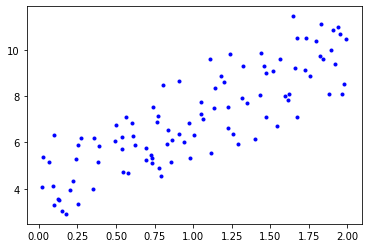

In [3]:
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt
x = 2*np.random.rand(100,1)
y=4+3*x+np.random.randn(100,1)
plt.plot(x,y,'b.')

Part 1: For comparison, solve the problem here using sklearn:

Part 2: Now solve using matrices and standard LS.

### Exercise 3 Create a seismic trace using the convolutional model
Create a seismic trace using a synthetic reflectivity function and a Ricker wavelet.\
You can calculate the Ricker wavelet using the original equation or from scipy 
* from scipy import signal
* ricker=signal.ricker(nt,amp)
* create your reflectivity (manually or using numpy.random)
* trace =signal.convolve(ricker, reflectivity, mode='same')

Optional 1: can you do this for every trace on the original gather you created before?\
Optional 2: can you do the deconvolution? (there is a signal.deconvolve module)